# FormFactor 財務分析 — Step 3a：同業比較 (Peer Comparison)

單看一家公司的數字，很難判斷好壞：毛利率 39% 算高還是低？2023 年營收掉 11% 是公司問題還是產業問題？
**要和同業比較才知道。**

這一步要：
1. 把 Step 1 的程式碼**包裝成函數**（`sec_etl.py`），一次抓 5 家公司
2. 全部放進**同一個資料庫**
3. 用 SQL 的 `PARTITION BY ticker`、`RANK()`、`ROW_NUMBER()` 做同業比較
4. 畫圖

### 同業怎麼選？

FormFactor 在半導體產業鏈的「**測試**」環節。選同業的原則是：**業務重疊、客戶相同、受同一個景氣循環影響**。

| 代號 | 公司 | 主要業務 | 和 FormFactor 的關係 |
|---|---|---|---|
| **FORM** | FormFactor | 探針卡（晶圓測試）、工程測試系統 | 主角 |
| **TER** | Teradyne | 自動測試設備 (ATE) | 同屬測試環節；探針卡要裝在 ATE 上一起用 |
| **COHU** | Cohu | 測試分選機、測試座、ATE | 同屬測試環節，規模相近 |
| **ONTO** | Onto Innovation | 製程量測與檢測，先進封裝檢測 | 同屬良率管理，同樣受惠先進封裝 |
| **KLIC** | Kulicke & Soffa | 封裝設備（打線、先進封裝） | 先進封裝產業鏈，同一群客戶 |

> ⚠️ **探針卡的直接競爭對手**（義大利 Technoprobe、日本 MJC、台灣中華精測）**不在美國上市**，SEC 沒有它們的資料。
> 它們的市占率會在 **Step 3b 市場分析**用產業報告的資料補上。這也是真實分析常遇到的限制：**資料取得難易度會影響你能做的比較**。

## 0. 環境設定

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import sec_etl   # ← 我們自己寫的模組（和這本 notebook 放在同一個資料夾）

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ⚠️ 和 Step 1 一樣，改成你自己的名字和 email（"User-Agent" 這個字不要改）
HEADERS = {"User-Agent": "Your Name your_email@example.com"}

BASE = Path.cwd()
RAW_DIR = BASE / "data" / "raw"
CLEAN_DIR = BASE / "data" / "clean"
OUT_DIR = BASE / "data" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = BASE / "data" / "formfactor.db"

PEERS = {
    # ticker: (CIK, 公司名稱, 業務分類, 會計年度結束)
    "FORM": ("1039399", "FormFactor",       "Probe cards & test systems", "Dec"),
    "TER":  ("97210",   "Teradyne",         "Automatic test equipment",   "Dec"),
    "COHU": ("21535",   "Cohu",             "Test handlers & contactors", "Dec"),
    "ONTO": ("704532",  "Onto Innovation",  "Metrology & inspection",     "Dec"),
    "KLIC": ("56978",   "Kulicke & Soffa",  "Assembly & packaging equip", "Sep/Oct"),
}

## 1. 把程式碼包成「模組」

Step 1 的 notebook 有 30 幾格，是為了**一步一步看懂**。現在要對 5 家公司做同樣的事，不可能複製貼上 5 次。

做法：把每個步驟寫成**函數 (function)**，放進 `sec_etl.py` 這個檔案（叫做「模組」），然後 `import` 進來用。

```python
def build_company(ticker, cik, headers):   # def = 定義函數，括號裡是「輸入」
    facts = fetch_companyfacts(...)         # 1. 擷取
    df = clean(flatten(facts))              # 2. 攤平 + 3. 清理
    fin_long, report = map_metrics(df)      # 4. 對應指標
    ...
    return fin_long, report                 # return = 函數的「輸出」
```

這叫做 **重構 (refactoring)**：功能不變，但程式碼變得可以重複使用。
可以用 VS Code 打開 `sec_etl.py` 看看，每個函數都對應 Step 1 的一節。

`build_company` 還多了一個功能：**快取 (cache)**。抓過的 JSON 會存在 `data/raw/`，下次執行直接讀檔案，不會重複打 SEC 的 API。

In [2]:
help(sec_etl.build_company)   # 看函數的說明

Help on function build_company in module sec_etl:

build_company(
    ticker,
    cik,
    headers,
    raw_dir='data/raw',
    n_years=10,
    use_cache=True
)
    擷取 → 攤平 → 清理 → 對應 → 推算，回傳 (長表格, 對應報告)



## 2. 一次抓 5 家公司

`for` 迴圈對每家公司呼叫 `build_company`，再用 `pd.concat` 把 5 張表疊成一張。
`try / except`：萬一某家公司出錯，印出錯誤訊息後**繼續跑下一家**，不會整個中斷。

In [3]:
all_long, all_reports = [], []
for ticker, (cik, name, segment, fy_end) in PEERS.items():
    try:
        long_df, report = sec_etl.build_company(ticker, cik, HEADERS, raw_dir=RAW_DIR)
        all_long.append(long_df)
        all_reports.append(report)
        years = f"{long_df.fiscal_year.min()}–{long_df.fiscal_year.max()}"
        print(f"✅ {ticker:5s} {name:18s} {len(long_df):4d} 列  年度 {years}")
    except Exception as e:
        print(f"❌ {ticker:5s} 失敗: {e}")

peers_long = pd.concat(all_long, ignore_index=True)
reports = pd.concat(all_reports, ignore_index=True)
print("\n合計:", peers_long.shape)

✅ FORM  FormFactor          279 列  年度 2016–2025
✅ TER   Teradyne            258 列  年度 2016–2025
✅ COHU  Cohu                266 列  年度 2016–2025
✅ ONTO  Onto Innovation     266 列  年度 2016–2025
✅ KLIC  Kulicke & Soffa     269 列  年度 2016–2025

合計: (1338, 9)


### 2.1 檢查：每家公司每個指標都有抓到嗎？

用 `pivot_table` 做成「公司 × 指標」的檢查表。`missing` 代表 5 個候選標籤都找不到，
可以用 Step 1 的 `find_concepts` 技巧去找那家公司用的標籤，再加進 `sec_etl.METRICS`。

In [4]:
check = reports.pivot_table(index="metric", columns="ticker", values="status", aggfunc="first")
check[(check != "ok").any(axis=1)]   # 只顯示有缺的指標；空白表格 = 全部都有

ticker,COHU,FORM,KLIC,ONTO,TER
metric,,,,,
sga_expense,ok,ok,ok,derived,ok
total_liabilities,derived,ok,ok,ok,ok


### 2.2 驗證：營收和公開資料對照

**每加一家公司就要驗證一次。** 下面是從各公司 10-K 查到的營收（百萬美元），跑出來的數字要一致：

| 公司 | 年度 | 公開營收 |
|---|---|---|
| FORM | 2025 | 785.0 |
| TER | 2025 | 3,190.0 |
| COHU | 2025 | 453.0 |
| ONTO | 2024 | 987.3 |
| KLIC | 2025（截至 2025-10-04） | 654.1 |

In [5]:
rev = (peers_long[peers_long["metric"] == "revenue"]
       .pivot_table(index="fiscal_year", columns="ticker", values="value") / 1e6)
rev.round(1)

ticker,COHU,FORM,KLIC,ONTO,TER
fiscal_year,,,,,
2016,282.10,383.90,627.20,221.10,"1,753.20"
2017,352.70,548.40,809.00,255.10,"2,136.60"
2018,451.80,529.70,889.10,273.80,"2,100.80"
2019,583.30,589.50,540.10,305.90,"2,295.00"
2020,636.00,693.60,623.20,556.50,"3,121.50"
2021,887.20,769.70,"1,517.70",788.90,"3,702.90"
2022,812.80,747.90,"1,503.60","1,005.20","3,155.00"
2023,636.30,663.10,742.50,815.90,"2,676.30"
2024,401.80,763.60,706.20,987.30,"2,819.90"


In [6]:
expected = {("FORM", 2025): 785.0, ("TER", 2025): 3190.0, ("COHU", 2025): 453.0,
            ("ONTO", 2024): 987.3, ("KLIC", 2025): 654.1}
for (t, y), v in expected.items():
    got = rev.loc[y, t] if (y in rev.index and t in rev.columns) else float("nan")
    flag = "✅" if abs(got - v) < 1 else "❌ 請檢查"
    print(f"{t:5s} {y}: 公開 {v:8,.1f}  抓到 {got:8,.1f}  {flag}")

FORM  2025: 公開    785.0  抓到    785.0  ✅
TER   2025: 公開  3,190.0  抓到  3,190.0  ✅
COHU  2025: 公開    453.0  抓到    453.0  ✅
ONTO  2024: 公開    987.3  抓到    987.3  ✅
KLIC  2025: 公開    654.1  抓到    654.1  ✅


In [7]:
peers_long.to_csv(CLEAN_DIR / "peers_financials_long.csv", index=False)
print("✅ 已輸出", CLEAN_DIR / "peers_financials_long.csv")

✅ 已輸出 C:\Users\User\Documents\FormFactor_Analysis\data\clean\peers_financials_long.csv


## 3. 放進資料庫

### 3.1 新增「公司資料表」(dimension table)

資料庫設計的基本觀念：
- **事實表 (fact table)**：放數字，例如 `financials`（每列一個數字）
- **維度表 (dimension table)**：放描述，例如 `companies`（公司名稱、業務分類）

兩張表用 `ticker` 連起來，需要時再 `JOIN`。這樣公司名稱只存一次，不用在 `financials` 的幾千列裡重複寫。
這叫做 **正規化 (normalization)**，是資料庫設計的核心概念。

In [8]:
conn = sqlite3.connect(DB_PATH)
def q(sql):
    return pd.read_sql_query(sql, conn)

companies = pd.DataFrame(
    [(t, cik, name, seg, fy) for t, (cik, name, seg, fy) in PEERS.items()],
    columns=["ticker", "cik", "company_name", "segment", "fiscal_year_end"],
)
conn.executescript('''
DROP TABLE IF EXISTS companies;
CREATE TABLE companies (
    ticker          TEXT PRIMARY KEY,
    cik             TEXT,
    company_name    TEXT,
    segment         TEXT,
    fiscal_year_end TEXT
);
''')
companies.to_sql("companies", conn, if_exists="append", index=False)
q("SELECT * FROM companies")

,ticker,cik,company_name,segment,fiscal_year_end
0,FORM,1039399,FormFactor,Probe cards & test systems,Dec
1,TER,97210,Teradyne,Automatic test equipment,Dec
2,COHU,21535,Cohu,Test handlers & contactors,Dec
3,ONTO,704532,Onto Innovation,Metrology & inspection,Dec
4,KLIC,56978,Kulicke & Soffa,Assembly & packaging equip,Sep/Oct


### 3.2 寫入財務資料（可重複執行的寫法）

Step 2 遇過 `UNIQUE constraint failed` 的錯誤。這次的寫法是：**先刪除這 5 家公司的舊資料，再寫入**。
不管執行幾次，結果都一樣（冪等 idempotent）。

`DELETE ... WHERE ticker IN (...)` 只刪這幾家，其他資料不受影響。

In [9]:
tickers = list(PEERS.keys())
placeholders = ",".join("?" * len(tickers))          # → "?,?,?,?,?"
conn.execute(f"DELETE FROM financials WHERE ticker IN ({placeholders})", tickers)
peers_long.to_sql("financials", conn, if_exists="append", index=False)
conn.commit()

q('''
SELECT f.ticker, c.company_name, COUNT(*) AS rows, MIN(fiscal_year) AS from_yr, MAX(fiscal_year) AS to_yr
FROM financials f
JOIN companies c ON f.ticker = c.ticker
GROUP BY f.ticker, c.company_name
ORDER BY f.ticker
''')

,ticker,company_name,rows,from_yr,to_yr
0,COHU,Cohu,266,2016,2025
1,FORM,FormFactor,279,2016,2025
2,KLIC,Kulicke & Soffa,269,2016,2025
3,ONTO,Onto Innovation,266,2016,2025
4,TER,Teradyne,258,2016,2025


### 3.3 重建 VIEW：Step 2 寫的 SQL 直接適用 5 家公司

Step 2 建 `fin_wide` 和 `ratios` 時就寫了 `GROUP BY ticker, fiscal_year`、`PARTITION BY ticker`，
所以**一行都不用改**，資料多了 4 家公司，VIEW 自動就包含它們。這就是一開始把 `ticker` 設計進去的好處。

（這裡重建一次，確保 VIEW 存在、欄位是最新的。）

In [10]:
metrics = q("SELECT DISTINCT metric FROM financials ORDER BY metric")["metric"].tolist()
case_lines = ",\n       ".join(f"MAX(CASE WHEN metric = '{m}' THEN value END) AS {m}" for m in metrics)
conn.execute("DROP VIEW IF EXISTS fin_wide")
conn.execute(f'''
CREATE VIEW fin_wide AS
SELECT ticker, fiscal_year,
       {case_lines}
FROM financials
GROUP BY ticker, fiscal_year
''')

conn.execute("DROP VIEW IF EXISTS ratios")
conn.execute('''
CREATE VIEW ratios AS
SELECT
    ticker, fiscal_year,
    revenue / 1e6                                              AS revenue_musd,
    100.0 * gross_profit     / NULLIF(revenue, 0)              AS gross_margin_pct,
    100.0 * operating_income / NULLIF(revenue, 0)              AS operating_margin_pct,
    100.0 * net_income       / NULLIF(revenue, 0)              AS net_margin_pct,
    100.0 * rd_expense       / NULLIF(revenue, 0)              AS rd_pct_revenue,
    100.0 * sga_expense      / NULLIF(revenue, 0)              AS sga_pct_revenue,
    100.0 * net_income       / NULLIF(total_assets, 0)         AS roa_pct,
    current_assets           / NULLIF(current_liabilities, 0)  AS current_ratio,
    total_liabilities        / NULLIF(total_equity, 0)         AS debt_to_equity,
    (operating_cash_flow - capex) / 1e6                        AS fcf_musd,
    100.0 * (operating_cash_flow - capex) / NULLIF(revenue, 0) AS fcf_margin_pct,
    (cash + COALESCE(st_investments, 0) - COALESCE(long_term_debt, 0)) / 1e6 AS net_cash_musd,
    100.0 * capex            / NULLIF(revenue, 0)              AS capex_pct_revenue,
    100.0 * stock_comp       / NULLIF(revenue, 0)              AS sbc_pct_revenue
FROM fin_wide
''')
conn.commit()
q("SELECT ticker, COUNT(*) AS years FROM ratios GROUP BY ticker")

,ticker,years
0,COHU,10
1,FORM,10
2,KLIC,10
3,ONTO,10
4,TER,10


## 4. 同業比較 SQL

### 4.1 最新年度快照：`ROW_NUMBER()`

每家公司的「最新年度」不一樣（KLIC 的年度在 9-10 月結束）。怎麼一次拿到每家公司最新的那一列？

`ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY fiscal_year DESC)`：
- `PARTITION BY ticker`：每家公司各自編號
- `ORDER BY fiscal_year DESC`：最新的年份排第 1

然後只留 `rn = 1` 的列。**「每組取最新／最大的一筆」是面試最常考的 SQL 題之一。**

In [11]:
latest = q('''
WITH ranked AS (
    SELECT r.*,
           ROW_NUMBER() OVER (PARTITION BY r.ticker ORDER BY r.fiscal_year DESC) AS rn
    FROM ratios r
)
SELECT c.company_name, k.fiscal_year,
       ROUND(k.revenue_musd, 0)         AS revenue_musd,
       ROUND(k.gross_margin_pct, 1)     AS gross_margin,
       ROUND(k.operating_margin_pct, 1) AS op_margin,
       ROUND(k.rd_pct_revenue, 1)       AS rd_pct,
       ROUND(k.capex_pct_revenue, 1)    AS capex_pct,
       ROUND(k.fcf_margin_pct, 1)       AS fcf_margin,
       ROUND(k.debt_to_equity, 2)       AS debt_to_equity
FROM ranked k
JOIN companies c ON k.ticker = c.ticker
WHERE k.rn = 1
ORDER BY k.revenue_musd DESC
''')
latest

,company_name,fiscal_year,revenue_musd,gross_margin,op_margin,rd_pct,capex_pct,fcf_margin,debt_to_equity
0,Teradyne,2025,"3,190.00",58.20,20.40,15.80,7.00,14.10,0.50
1,Onto Innovation,2025,"1,005.00",49.70,13.20,13.10,2.80,29.80,0.13
2,FormFactor,2025,785.00,39.30,7.30,14.70,13.20,1.50,0.18
3,Kulicke & Soffa,2025,654.00,42.50,-0.50,22.90,2.60,14.70,0.34
4,Cohu,2025,453.00,42.70,-15.40,20.40,4.60,2.40,0.58


### 4.2 景氣循環：誰在 2023 年跌最深？

用 `LAG ... OVER (PARTITION BY ticker ...)` 算每家公司的營收年增率，再用 `CASE WHEN` 把公司轉成欄位，方便橫向比較。

> ⚠️ KLIC 的會計年度在 9-10 月結束，所以它的「2023」大約是 2022/10 到 2023/9，和其他公司差了一季。比較時要記得這個落差。

In [12]:
q('''
WITH yoy AS (
    SELECT ticker, fiscal_year,
           100.0 * (revenue_musd - LAG(revenue_musd) OVER w) / LAG(revenue_musd) OVER w AS rev_yoy
    FROM ratios
    WINDOW w AS (PARTITION BY ticker ORDER BY fiscal_year)
)
SELECT fiscal_year,
       ROUND(MAX(CASE WHEN ticker = 'FORM' THEN rev_yoy END), 1) AS FORM,
       ROUND(MAX(CASE WHEN ticker = 'TER'  THEN rev_yoy END), 1) AS TER,
       ROUND(MAX(CASE WHEN ticker = 'COHU' THEN rev_yoy END), 1) AS COHU,
       ROUND(MAX(CASE WHEN ticker = 'ONTO' THEN rev_yoy END), 1) AS ONTO,
       ROUND(MAX(CASE WHEN ticker = 'KLIC' THEN rev_yoy END), 1) AS KLIC
FROM yoy
WHERE fiscal_year >= 2019
GROUP BY fiscal_year
ORDER BY fiscal_year
''')

,fiscal_year,FORM,TER,COHU,ONTO,KLIC
0,2019,11.30,9.20,29.10,11.70,-39.30
1,2020,17.70,36.00,9.00,81.90,15.40
2,2021,11.00,18.60,39.50,41.80,143.50
3,2022,-2.80,-14.80,-8.40,27.40,-0.90
4,2023,-11.30,-15.20,-21.70,-18.80,-50.60
5,2024,15.20,5.40,-36.90,21.00,-4.90
6,2025,2.80,13.10,12.70,1.80,-7.40


### 4.3 營收指數化：把大小不同的公司放在同一條起跑線

Teradyne 營收約 30 億美元，Cohu 約 4 億，直接畫在一起看不出成長差異。
**指數化**：把每家公司 2019 年的營收設為 100，之後每年 = 當年營收 ÷ 2019 營收 × 100。

`FIRST_VALUE(revenue) OVER (PARTITION BY ticker ORDER BY fiscal_year)` = 每家公司排序後的**第一個值**（也就是 2019 年）。

In [15]:
idx = q('''

SELECT ticker, fiscal_year,
       100.0 * revenue_musd / FIRST_VALUE(revenue_musd) OVER (PARTITION BY ticker ORDER BY fiscal_year) AS rev_index
FROM ratios
WHERE fiscal_year >= 2020
ORDER BY ticker, fiscal_year
''')
idx_wide = idx.pivot(index="fiscal_year", columns="ticker", values="rev_index")[list(PEERS.keys())]
idx_wide.round(0)

ticker,FORM,TER,COHU,ONTO,KLIC
fiscal_year,,,,,
2020,100.00,100.00,100.00,100.00,100.00
2021,111.00,119.00,139.00,142.00,244.00
2022,108.00,101.00,128.00,181.00,241.00
2023,96.00,86.00,100.00,147.00,119.00
2024,110.00,90.00,63.00,177.00,113.00
2025,113.00,102.00,71.00,181.00,105.00


### 4.4 畫圖：營收指數

畫圖的幾個原則（專業報告都這樣做）：
- **每家公司固定一個顏色**，之後每張圖都一樣，讀者不用重新對照
- **直接在線尾標公司名稱**，比看圖例快
- 主角 FormFactor 用較粗的線突出
- 格線淡、去掉上方和右方的邊框，讓視線集中在資料

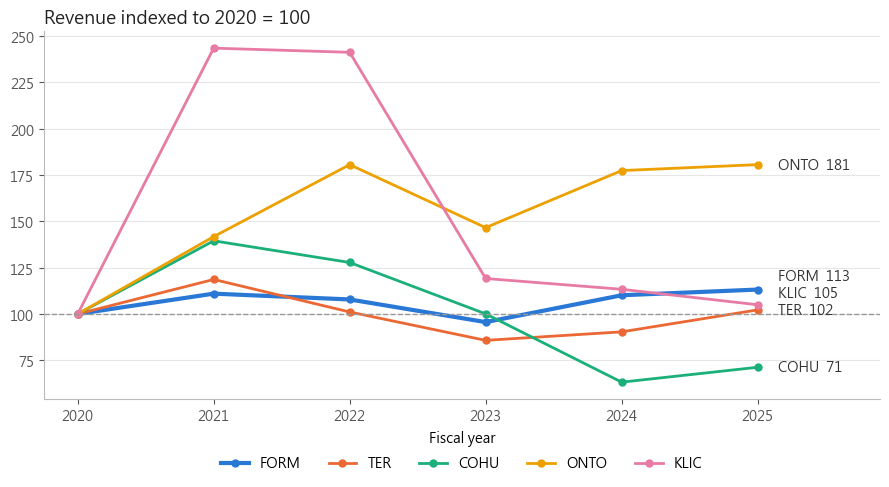

In [18]:
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Noto Sans CJK TC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

COLORS = {"FORM": "#2a78d6", "TER": "#eb6834", "COHU": "#1baf7a", "ONTO": "#eda100", "KLIC": "#e87ba4"}

def style(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bbbbbb")
    ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#555555")

fig, ax = plt.subplots(figsize=(9, 5))
for t in idx_wide.columns:
    s = idx_wide[t].dropna()
    ax.plot(s.index, s.values, color=COLORS[t], linewidth=3 if t == "FORM" else 2,
            marker="o", markersize=5, label=t)
# 線尾標籤：依數值排序，太靠近的往上下推開，避免文字重疊
ends = idx_wide.ffill().iloc[-1].sort_values()
gap = (idx_wide.max().max() - idx_wide.min().min()) * 0.05
label_y, prev = {}, None
for t, v in ends.items():
    y = v if prev is None else max(v, prev + gap)
    label_y[t], prev = y, y
last_x = idx_wide.index.max()
for t, v in ends.items():
    ax.text(last_x + 0.15, label_y[t], f"{t}  {v:.0f}", va="center", color="#333333", fontsize=10)
ax.set_xlim(right=last_x + 0.9)
ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
ax.set_title("Revenue indexed to 2020 = 100", loc="left", fontsize=13, color="#222222")
ax.set_xlabel("Fiscal year")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "peer_revenue_index.png", dpi=150)
plt.show()

### 4.5 長期平均：`GROUP BY` + `RANK()`

用 2021–2025 五年平均來比較，減少單一年度的雜訊。
`RANK() OVER (ORDER BY ... DESC)` 幫每個指標排名次（1 = 最高）。

> ⚠️ FormFactor 2023 年的營業利益率包含 $73M 出售利益（Step 2 發現的）。
> 這裡用 Step 2 建立的 `one_time_items` 表扣除；如果你沒有建那張表，下面會自動建立。

In [19]:
conn.executescript('''
CREATE TABLE IF NOT EXISTS one_time_items (
    ticker TEXT, fiscal_year INTEGER, item TEXT, amount REAL, source TEXT,
    PRIMARY KEY (ticker, fiscal_year, item)
);
INSERT OR IGNORE INTO one_time_items VALUES
    ('FORM', 2023, 'Gain on sale of FRT business', 73.0e6, 'FY2023 Q4 earnings release');
''')
conn.commit()

avg5 = q('''
WITH adj AS (
    SELECT ticker, fiscal_year, SUM(amount) AS one_time FROM one_time_items GROUP BY ticker, fiscal_year
),
base AS (
    SELECT r.ticker, r.fiscal_year, r.gross_margin_pct, r.rd_pct_revenue, r.capex_pct_revenue, r.fcf_margin_pct,
           100.0 * (f.operating_income - COALESCE(a.one_time, 0)) / f.revenue AS adj_op_margin_pct
    FROM ratios r
    JOIN fin_wide f ON r.ticker = f.ticker AND r.fiscal_year = f.fiscal_year
    LEFT JOIN adj a ON r.ticker = a.ticker AND r.fiscal_year = a.fiscal_year
    WHERE r.fiscal_year BETWEEN 2021 AND 2025
),
summary AS (
    SELECT ticker,
           AVG(gross_margin_pct)  AS gross_margin,
           AVG(adj_op_margin_pct) AS op_margin_adj,
           AVG(rd_pct_revenue)    AS rd_pct,
           AVG(capex_pct_revenue) AS capex_pct,
           AVG(fcf_margin_pct)    AS fcf_margin
    FROM base
    GROUP BY ticker
)
SELECT ticker,
       ROUND(gross_margin, 1)  AS gross_margin,  RANK() OVER (ORDER BY gross_margin  DESC) AS gm_rank,
       ROUND(op_margin_adj, 1) AS op_margin_adj, RANK() OVER (ORDER BY op_margin_adj DESC) AS opm_rank,
       ROUND(rd_pct, 1)        AS rd_pct,        RANK() OVER (ORDER BY rd_pct        DESC) AS rd_rank,
       ROUND(capex_pct, 1)     AS capex_pct,
       ROUND(fcf_margin, 1)    AS fcf_margin,    RANK() OVER (ORDER BY fcf_margin    DESC) AS fcf_rank
FROM summary
ORDER BY op_margin_adj DESC
''')
avg5

,ticker,gross_margin,gm_rank,op_margin_adj,opm_rank,rd_pct,rd_rank,capex_pct,fcf_margin,fcf_rank
0,TER,58.60,1,23.80,1,14.70,4,5.80,17.20,2
1,ONTO,52.30,2,10.00,3,12.20,5,2.40,20.40,1
2,KLIC,44.90,4,10.00,2,16.40,1,2.80,15.40,3
3,FORM,40.00,5,7.50,4,15.20,3,8.80,6.30,5
4,COHU,45.20,3,2.30,5,15.40,2,2.60,7.10,4


### 4.6 畫圖：五年平均比較（小圖組 small multiples）

四個指標的單位、大小都不同，**不要硬塞進同一張圖**。分成四張小圖並排，每張只比一件事。

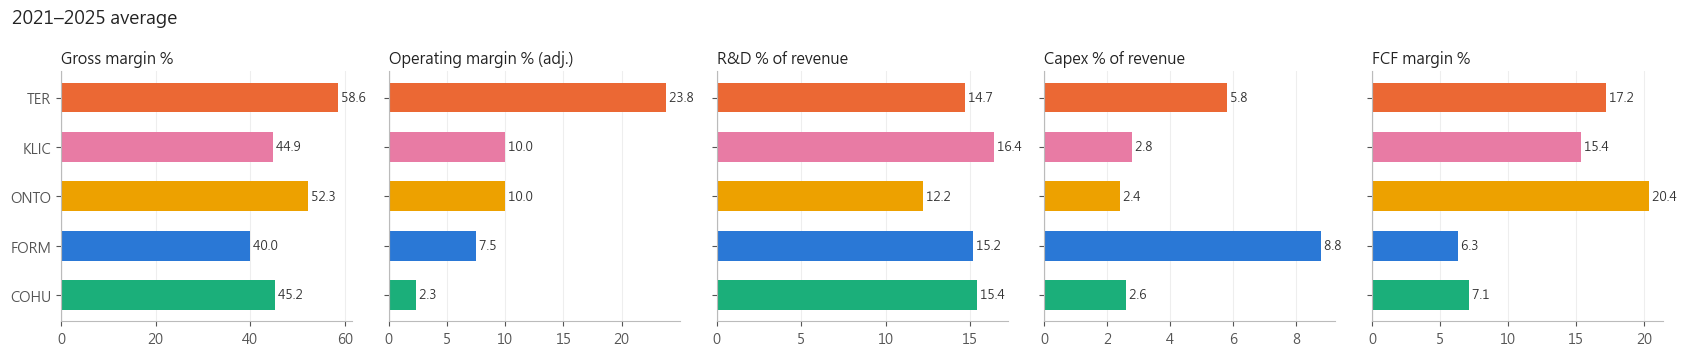

In [23]:
panels = [("gross_margin", "Gross margin %"), ("op_margin_adj", "Operating margin % (adj.)"),
          ("rd_pct", "R&D % of revenue"), ("capex_pct", "Capex % of revenue"),
          ("fcf_margin", "FCF margin %")]
order = avg5.sort_values("op_margin_adj")["ticker"].tolist()   # 每張圖用同樣的公司順序

fig, axes =plt.subplots(1, 5, figsize=(17, 3.6), sharey=True)
for ax, (col, title) in zip(axes, panels):
    d = avg5.set_index("ticker").loc[order, col]
    ax.barh(d.index, d.values, color=[COLORS[t] for t in d.index], height=0.6)
    for y, v in enumerate(d.values):
        ax.text(v, y, f" {v:.1f}", va="center", fontsize=9, color="#333333")
    ax.set_title(title, loc="left", fontsize=11, color="#222222")
    ax.axvline(0, color="#999999", linewidth=0.8)
    style(ax)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", color="#eeeeee")
fig.suptitle("2021–2025 average", x=0.01, ha="left", fontsize=13, color="#222222")
plt.tight_layout()
plt.savefig(OUT_DIR / "peer_margins_5yr.png", dpi=150)
plt.show()

### 4.7 景氣敏感度：波動有多大？

SQLite 沒有標準差函數 `STDEV()`（PostgreSQL、Snowflake 有），所以用 SQL 撈資料、pandas 算統計。
**營收年增率的標準差越大 = 越受景氣循環影響**，投資風險越高。

In [25]:
conn = sqlite3.connect(DB_PATH)

In [26]:
yoy = q('''

SELECT ticker, fiscal_year,
       100.0 * (revenue_musd - LAG(revenue_musd) OVER w) / LAG(revenue_musd) OVER w AS rev_yoy,
       operating_margin_pct
FROM ratios
WINDOW w AS (PARTITION BY ticker ORDER BY fiscal_year)
''')
cyc = (yoy[yoy["fiscal_year"] >= 2017]
       .groupby("ticker")
       .agg(avg_growth=("rev_yoy", "mean"), growth_volatility=("rev_yoy", "std"),
            worst_year_growth=("rev_yoy", "min"), opm_volatility=("operating_margin_pct", "std"))
       .round(1)
       .sort_values("growth_volatility"))
cyc

,avg_growth,growth_volatility,worst_year_growth,opm_volatility
ticker,,,,
FORM,9.20,15.90,-11.30,2.40
TER,8.10,16.90,-15.20,4.50
COHU,8.50,25.80,-36.90,14.10
ONTO,21.10,28.40,-18.80,14.90
KLIC,10.50,55.90,-50.60,13.90


## 5. 輸出

In [28]:
latest.to_csv(OUT_DIR / "peer_latest_snapshot.csv", index=False)
avg5.to_csv(OUT_DIR / "peer_5yr_average.csv", index=False)
idx_wide.round(1).to_csv(OUT_DIR / "peer_revenue_index.csv")
cyc.to_csv(OUT_DIR / "peer_cyclicality.csv")
conn.close()
print("✅ 輸出到", OUT_DIR)
for p in sorted(OUT_DIR.glob("peer_*")):
    print("  ", p.name)

✅ 輸出到 C:\Users\User\Documents\FormFactor_Analysis\data\analysis
   peer_5yr_average.csv
   peer_cyclicality.csv
   peer_latest_snapshot.csv
   peer_margins_5yr.png
   peer_revenue_index.csv
   peer_revenue_index.png


## 📝 解讀問題（報告「同業比較」段落的骨架）

1. **規模**：FormFactor 在這群公司裡算大還是小？規模小有什麼劣勢（議價能力、研發資源）？
2. **成長**：看營收指數圖，2019 年以來誰成長最多？FormFactor 落在哪裡？成長最快的公司做對了什麼？
3. **2023 年景氣下行**：FormFactor 跌幅比同業大還是小？這可以回答 Step 2 的問題：「2023 年獲利大跌是公司的問題，還是產業的問題？」
4. **獲利能力**：FormFactor 的毛利率排第幾？營業利益率排第幾？如果毛利率不差、營業利益率卻偏低，問題出在哪？（提示：看研發費用率）
5. **投資強度**：FormFactor 的研發和資本支出比例和同業比如何？高投入是「為未來佈局」還是「效率不佳」？要怎麼判斷？
6. **風險**：誰的營收波動最大？為什麼這種公司的股價通常也波動較大？

## ✏️ 練習題
1. 用 `ROW_NUMBER()` 找出**每家公司營業利益率最高的那一年**
2. 用 `RANK() OVER (PARTITION BY fiscal_year ORDER BY gross_margin_pct DESC)` 看 FormFactor **每年**的毛利率排名有沒有變化
3. 在 `PEERS` 加入一家公司（例如 **KLA, CIK 319201** 或 **Aehr Test Systems, CIK 1040470**），整本重跑，看看你的程式能不能直接處理新公司

**下一步 → Step 3b 市場結構分析**：探針卡市場規模與市占率（Technoprobe、MJC 等）、FormFactor 的上下游與主要客戶、營收結構（晶圓代工／DRAM／Flash），以及 HBM、先進封裝帶來的機會。